# Low discrepancy sequence testing

Function initialization:

In [35]:
from QMC_option_pricing import Kronecker, Halton, Sobol

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import entropy
import time

%matplotlib inline

def gap_metrics(gaps):
    gaps = np.asarray(gaps).squeeze()

    # variance
    var = np.var(gaps, ddof=1)

    # max / min gap
    max_gap = np.max(gaps)
    min_gap = np.min(gaps)

    # avoid division by zero
    ratio = np.inf if min_gap == 0 else max_gap / min_gap

    # normalized distribution for entropy
    # add small epsilon to avoid log(0)
    eps = 1e-12
    probs = gaps + eps
    probs = probs / np.sum(probs)

    ent = entropy(probs, base=np.e)

    return var, max_gap, ratio, ent

Parameters:

In [36]:
n = int(1e7)
bins = 100
maxiter = 8

## Number generation histogram

Text(0.5, 0, 'Value')

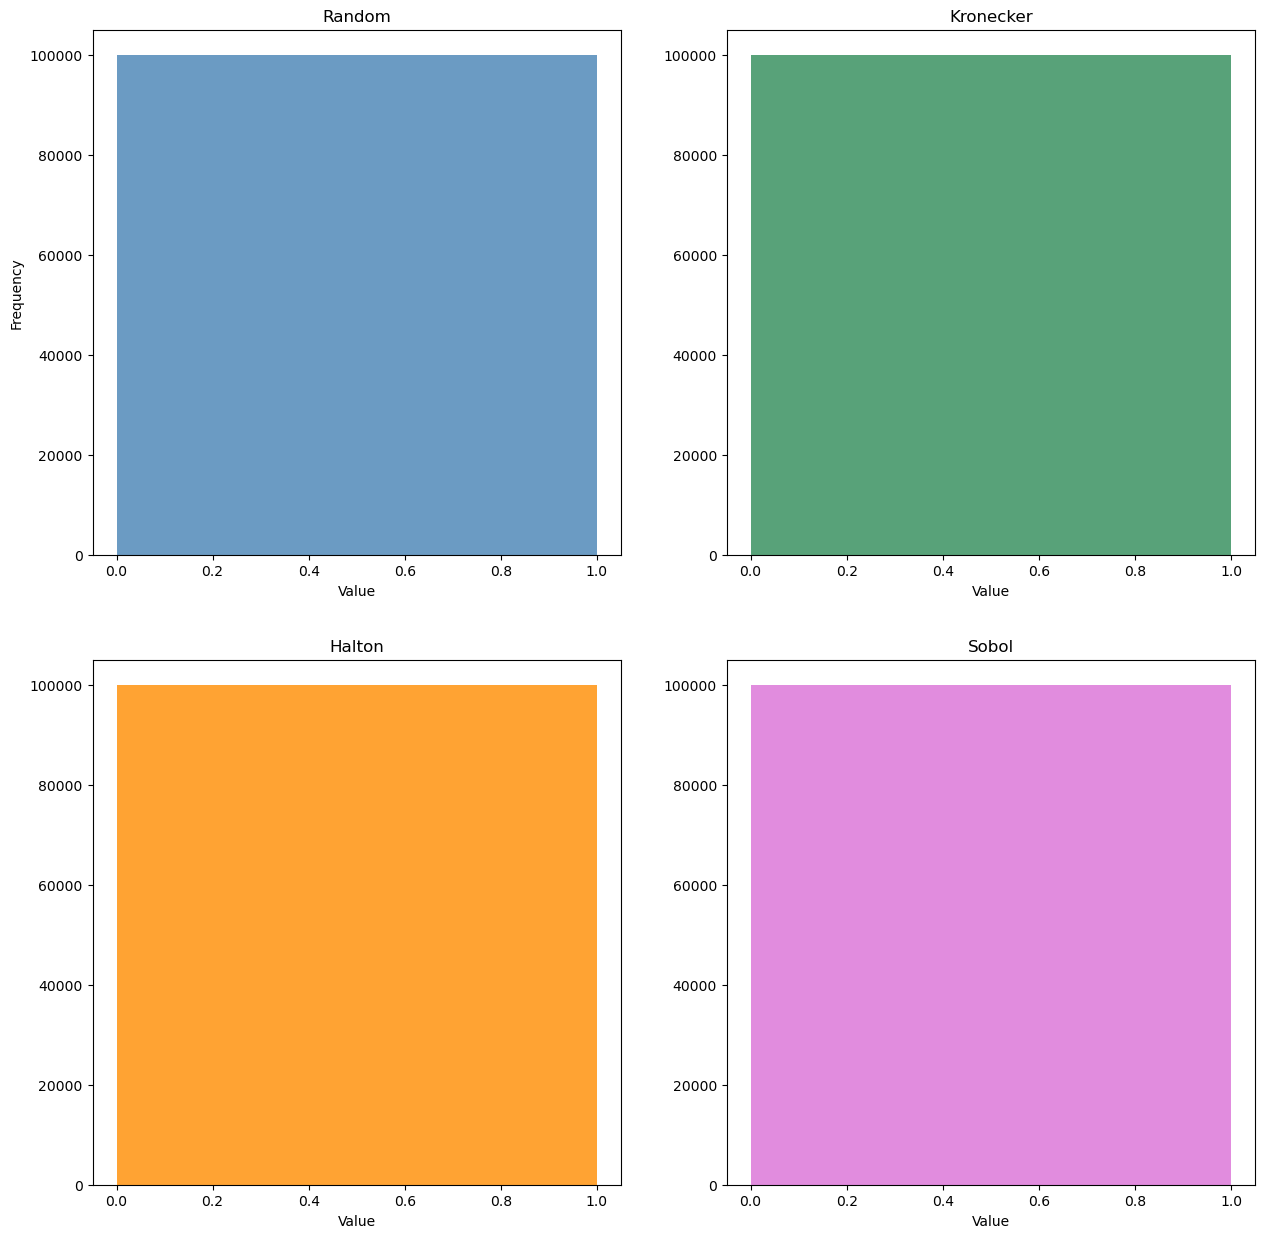

In [49]:
N = np.random.rand(n,1)
K = Kronecker(n,1)
H = Halton(n,1)
S = Sobol(n,1)

fig, axes = plt.subplots(2,2, figsize=(15, 15))

axes[0,0].hist(K, bins=bins, color='steelblue', alpha=0.8)
axes[0,0].set_title('Random')
axes[0,0].set_xlabel('Value')
axes[0,0].set_ylabel('Frequency')

axes[0,1].hist(K, bins=bins, color='seagreen', alpha=0.8)
axes[0,1].set_title('Kronecker')
axes[0,1].set_xlabel('Value')

axes[1,0].hist(H, bins=bins, color='darkorange', alpha=0.8)
axes[1,0].set_title('Halton')
axes[1,0].set_xlabel('Value')

axes[1,1].hist(S, bins=bins, color='orchid', alpha=0.8)
axes[1,1].set_title('Sobol')
axes[1,1].set_xlabel('Value')

Generated numbers are visually uniform over (0,1), but for high sample numbers this test isn't conclusive on its own.

## Generator metrics

Histograms serve as a sanity check, but more precise metrics can be calculated.

In [50]:
N = np.random.rand(n,1)
K = Kronecker(n,1)
H = Halton(n,1)
S = Sobol(n,1)

N_sorted = np.sort(N, axis=0)
K_sorted = np.sort(K, axis=0)
H_sorted = np.sort(H, axis=0)
S_sorted = np.sort(S, axis=0)

N_gap = np.diff(N_sorted, axis=0)
K_gap = np.diff(K_sorted, axis=0)
H_gap = np.diff(H_sorted, axis=0)
S_gap = np.diff(S_sorted, axis=0)

N_var, N_max, N_ratio, N_ent = gap_metrics(N_gap)
K_var, K_max, K_ratio, K_ent = gap_metrics(K_gap)
H_var, H_max, H_ratio, H_ent = gap_metrics(H_gap)
S_var, S_max, S_ratio, S_ent = gap_metrics(S_gap)

print("Random noise sequence metrics:")
print(f"  variance: {N_var:.6e}")
print(f"  max gap:  {N_max:.6e}")
print(f"  max/min:  {N_ratio:.6f}")
print(f"  entropy:  {N_ent:.6f}")

print("Kronecker sequence metrics:")
print(f"  variance: {K_var:.6e}")
print(f"  max gap:  {K_max:.6e}")
print(f"  max/min:  {K_ratio:.6f}")
print(f"  entropy:  {K_ent:.6f}")

print("\nHalton sequence metrics:")
print(f"  variance: {H_var:.6e}")
print(f"  max gap:  {H_max:.6e}")
print(f"  max/min:  {H_ratio:.6f}")
print(f"  entropy:  {H_ent:.6f}")

print("\nSobol sequence metrics:")
print(f"  variance: {S_var:.6e}")
print(f"  max gap:  {S_max:.6e}")
print(f"  max/min:  {S_ratio:.6f}")
print(f"  entropy:  {S_ent:.6f}")

Random noise sequence metrics:
  variance: 1.000474e-14
  max gap:  2.074600e-06
  max/min:  491745703.131579
  entropy:  15.695169
Kronecker sequence metrics:
  variance: 7.686285e-16
  max gap:  1.275912e-07
  max/min:  2.631453
  entropy:  16.077905

Halton sequence metrics:
  variance: 7.759663e-16
  max gap:  1.192093e-07
  max/min:  2.000000
  entropy:  16.075535

Sobol sequence metrics:
  variance: 7.761796e-16
  max gap:  2.384186e-07
  max/min:  4.000000
  entropy:  16.075526


## Variance versus computation cost comparison

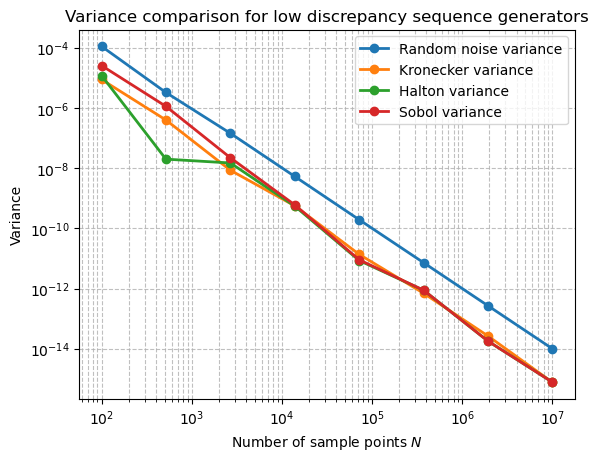

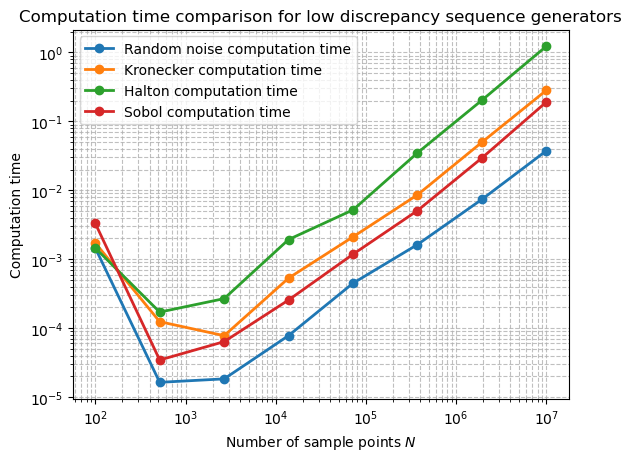

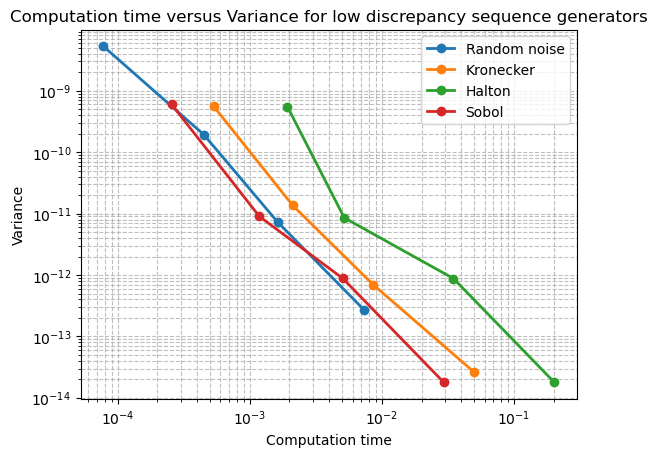

In [52]:
N_variance = np.zeros(maxiter)
N_time = np.zeros(maxiter)

K_variance = np.zeros(maxiter)
K_time = np.zeros(maxiter)

H_variance = np.zeros(maxiter)
H_time = np.zeros(maxiter)

S_variance = np.zeros(maxiter)
S_time = np.zeros(maxiter)

N = np.logspace(2, maxiter-1, maxiter, dtype=int)

for i, n in enumerate(N):
    start = time.perf_counter()
    Ns = np.random.rand(n,1)
    N_time[i] = time.perf_counter() - start

    N_sorted = np.sort(Ns, axis=0)
    N_gap = np.diff(N_sorted, axis=0)
    N_variance[i] = np.var(N_gap, ddof=1)
    
    start = time.perf_counter()
    K = Kronecker(n,1)
    K_time[i] = time.perf_counter() - start

    K_sorted = np.sort(K, axis=0)
    K_gap = np.diff(K_sorted, axis=0)
    K_variance[i] = np.var(K_gap, ddof=1)

    start = time.perf_counter()
    H = Halton(n,1)
    H_time[i] = time.perf_counter() - start

    H_sorted = np.sort(H, axis=0)
    H_gap = np.diff(H_sorted, axis=0)
    H_variance[i] = np.var(H_gap, ddof=1)

    start = time.perf_counter()
    S = Sobol(n,1)
    S_time[i] = time.perf_counter() - start

    S_sorted = np.sort(S, axis=0)
    S_gap = np.diff(S_sorted, axis=0)
    S_variance[i] = np.var(S_gap, ddof=1)

plt.loglog(N,N_variance,'o-',lw=2,label='Random noise variance')
plt.loglog(N,K_variance,'o-',lw=2,label='Kronecker variance')
plt.loglog(N,H_variance,'o-',lw=2,label='Halton variance')
plt.loglog(N,S_variance,'o-',lw=2,label='Sobol variance')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Number of sample points $N$')
plt.ylabel('Variance')
plt.title('Variance comparison for low discrepancy sequence generators')
plt.legend()
plt.show()

# Computation time plot

plt.loglog(N,N_time,'o-',lw=2,label='Random noise computation time')
plt.loglog(N,K_time,'o-',lw=2,label='Kronecker computation time')
plt.loglog(N,H_time,'o-',lw=2,label='Halton computation time')
plt.loglog(N,S_time,'o-',lw=2,label='Sobol computation time')


plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Number of sample points $N$')
plt.ylabel('Computation time')
plt.title(f'Computation time comparison for low discrepancy sequence generators')
plt.legend()
plt.show()

# Variance vs computation time

plt.loglog(N_time[3:-1],N_variance[3:-1], 'o-',lw=2,label='Random noise')
plt.loglog(K_time[3:-1],K_variance[3:-1], 'o-',lw=2,label='Kronecker')
plt.loglog(H_time[3:-1],H_variance[3:-1], 'o-',lw=2,label='Halton')
plt.loglog(S_time[3:-1],S_variance[3:-1], 'o-',lw=2,label='Sobol')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Computation time')
plt.ylabel('Variance')
plt.title(f'Computation time versus Variance for low discrepancy sequence generators')
plt.legend()
plt.show()

Due to the first computation time estimates being noisy (as initialization time dominates over calculation time), they are ommited on the variance vs computation time graph, so the data shown is cleaner.